## Introducción

El objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
Para ello se trabajará con datos reales de TomTom Traffic Index y OECD Cities, que deberan limpiarse, combinarse y analizarse para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## Carga de archivos


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # importar librerías

In [3]:
# carga de archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv') 

In [4]:
traffic.head() # mostrar las primeras 5 filas de traffic

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [5]:
eco.head() # mostrar las primeras 5 filas de eco

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



---

## Exploración de los datos y tipos de datos



In [6]:
traffic.info()
traffic.head(3) # Examinar la estructura de traffic


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` son de tipo object, convertir a datetime.
- Los nombres de las columnas no tienen espacios entre palabras.

In [7]:
eco.info() # Examinar la estructura de eco
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


En la estructura del DF eco, se observa que:
- Las columnas `'City GDP/capita', 'Unemployment %, 'PM2.5 (μg/m³)', 'Population (M)'` son tipo object, deben ser float
- La columnas `'City GDP/capita', 'Unemployment %', 'PM2.5 (μg/m³)', 'Population (M)'` contienen simbolos o información innecesaria.

## Estandarización de nombres de columnas


In [13]:
# Automatizacion de la estandarización los nombres de las columnas de traffic
def estandarizar_cols(df,rename_dict):
    df.columns = df.columns.str.lower()
    df= df.rename(columns={'updatetimeutc':'update_time_utc',
                        'jamsdelay':'jams_delay',
                        'trafficindexlive':'traffic_index_live',
                        'jamslengthinkms':'jams_length_kms',
                        'jamscount':'jams_count',
                        'trafficindexweekago':'traffic_index_week_ago',
                        'updatetimeutcweekago':'update_time_utc_week_ago',
                        'traveltimeliveper10kmsmins':'travel_time_live_per_10kms_mins',
                        'traveltimehistoricper10kmsmins':'travel_time_hist_per_10kms_mins',
                        'minsdelay':'mins_delay'})
    return df
# verificar cambios
print(traffic.columns)


Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')


In [15]:
# Automatizacion de la estandarización los nombres de las columnas de eco
def estandarizar_cols(df,rename_dict):
    df.columns = df.columns.str.lower()
    df = df.rename(columns={'city gdp/capita':'city_gdp_capita','unemployment %':'unemployment_pct','pm2.5 (μg/m³)':'pm25','population (m)':'population_m'})
    return df
# verificar cambios
print(eco.columns)

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')



### Corrección de formatos numéricos y de fecha


In [16]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'],errors='coerce') 
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'],errors='coerce')

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   country                          1004464 non-null  object        
 1   city                             1004464 non-null  object        
 2   update_time_utc                  1004464 non-null  datetime64[ns]
 3   jams_delay                       1004464 non-null  float64       
 4   traffic_index_live               1004464 non-null  float64       
 5   jams_length_kms                  1004464 non-null  float64       
 6   jams_count                       1004464 non-null  float64       
 7   traffic_index_week_ago           1004464 non-null  float64       
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins  1004464 non-null  float64       
 10  travel_time_hist_per_10kms_min

In [17]:
# Limpieza de separadores y conversion de columnas numéricas en eco a tipo float
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float) 
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%','').str.replace(',','.').astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace(',','.').astype(float)

# Se calculo la población total en unidades absolutas (Multiplica * 1000000) como columna adicional
eco['population'] = eco['population_m'] * 1_000_000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0



---

## Extracción de año y filtrar 2024


In [18]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
traffic.head(3) 

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [19]:
# Filtración de los registros del año 2024
traffic_2024 = traffic[traffic['year']==2024].copy()
eco_2024 = eco[eco['year']==2024].copy()

# Revisión de dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0



---

## Análisis y resumen de datos de movilidad


In [20]:
# Calculo de los promedios de trafico por ciudad, país y año
traffic_city_year_2024 = traffic_2024.groupby(['city','country','year'])['jams_delay','traffic_index_live','jams_length_kms','jams_count','mins_delay','travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins'].mean().reset_index()

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [21]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False) # se ordena de mayor a menor para obtener la ciudad con mayor tiempo promedio de tráfico

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es la Ciudad de México.


---

## Unión de movilidad y economía


In [22]:
# Selección de las columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unión de datasets
merged = pd.merge(traffic_2024_small,eco_2024_small,on=['city','year'],how='inner') 

# Mostrar las primeras 5 filas
merged.head() 

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0



---

## Visualización y análisis de relaciones



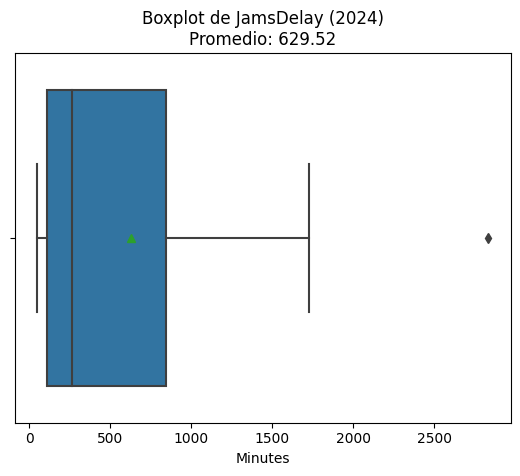

In [23]:

# Boxplot para observar el comportamiento de los minutos de congestion JamsDelay

sns.boxplot(data=merged,x='jams_delay',showmeans=True)
# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.xlabel('Minutes')
plt.show()




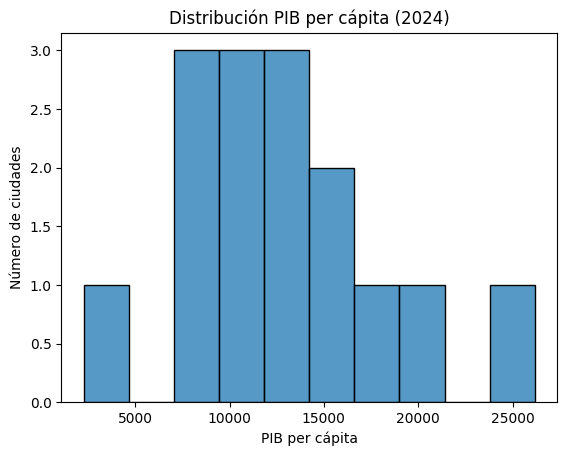

In [24]:
# Histograma para ver la distribución de la economía (city_gdp_capita)
sns.histplot(data=merged, x='city_gdp_capita',bins=10)
plt.title('Distribución PIB per cápita (2024)')
plt.xlabel('PIB per cápita')
plt.ylabel('Número de ciudades')
plt.show()



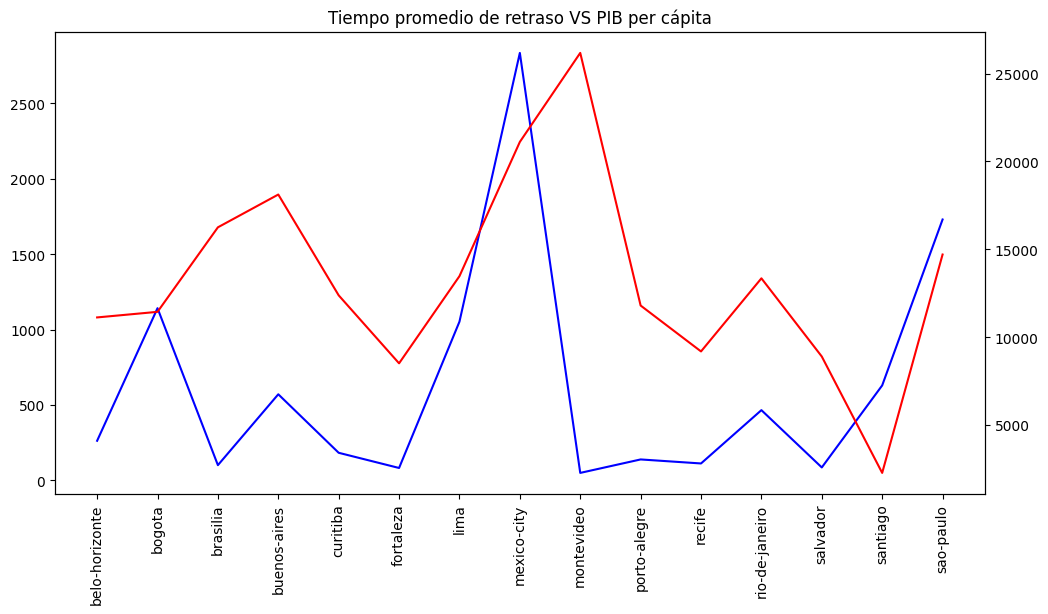

In [27]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(merged["city"], merged["jams_delay"], color="blue", label="Jams Delay")
ax1.tick_params(axis='x', rotation=90)
ax2=ax1.twinx()
ax2.plot(merged["city"],merged["city_gdp_capita"], color="red", label="GDP")
plt.title("Tiempo promedio de retraso VS PIB per cápita")
plt.show()

Ciudad de México es la ciudad con el mayor tiempo perdido en atascos y destaca también con uno de los PIB más altos. Montevideo, por su parte presenta el mayor PIB y la mejor movilidad, sin embargo, es un caso aislado, ya que otras ciudades (Fortaleza, Recife, Salvador, por ejemplo) con buena movilidad no tienen un PIB alto. Por otro lado, ciudades como Bogotá, Sao Paulo y Lima presentan una movilidad deficiente y un PIB dentro de la media.


---

## Exportación y documentación de resultados


In [99]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)
import os

tamaño = os.path.getsize("ladb_mobility_economy_2024_clean.csv")
print(f"El archivo pesa: {tamaño} bytes")

El archivo pesa: 2906 bytes


# Resumen ejecutivo 


**Contexto & objetivo:**  
- Responde la pregunta central del análisis: ¿qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?

No se observa una relación fuerte entre congestión urbana y PIB per cápita. Si bien la correlación existe, ésta es debil, lo que sugiere que las ciudades con mayor actividad ecónómica pueden presentar más congestión sin que ello disminuya significativamente su productividad. Sin embargo, la evidencia indica que los congestionamientos afectan a la calidad de vida y la eficiencia urbana.

- Explica brevemente las variables clave utilizadas y su relevancia para la toma de decisiones.

Para este analisis se tomaron en cuenta las siguientes variables:

1. city_gdp_capita, porque mide el PIB per capita, es el principal indicador de productividad económica.
2. traffic_index_live, ya que indica el nivel de congestión vial, lo que nos ayuda a identificar las ciudades con mayores problemas de movilidad.
3. travel_time_live_per _10kms_mins, mide el tiempo promedio que se demora en recorrer 10 kilometros, lo que ayuda a determinar la eficiencia del sistema de transporte.
4. jams_delay, determina el tiempo de retraso acumulado causado por la congestion, nos ayuda a calcular el costo temporal generado por el tráfico.

Es importante no basarse únicamente en el PIB per cápita para la toma de decisiones para inversión, sino tomar en cuenta la combinación de alta congestión urbana y tiempos de transporte elevados, pues al haber una mejoría en la movilidad e infraestructura, aumentan las ganancias, la competitividad y la calidad de vida.

**Cobertura de datos:**  
- Especifica los años analizados, número de ciudades y países incluidos.

El análisis se enfoco en el año 2024, se consideraron 15 ciudades de América Latina de siete países: México, Colombia, Argentina, Perú, Brasil, Chile y Uruguay.

**Metodología (alto nivel):**  
- Describe los procesos principales: limpieza de datos (formatos, estandarización de columnas).

Previo a la unión de dataframes, se hizo una exploración de los mismos para determinar si los tipos de datos eran correctos para cada columna. Antes de los cambios de formato de los datos, se estandarizo el nombre de las columnas en los dos dataframes para que tengan el formato snake_case. 
En el df traffic, había valores de fecha que estaban como tipo object, se hizo la conversion con pd.to_dataframe y errors='coerce' para que sea a prueba de errores. 
En eco, había valores float marcados como object, se cambiaron los separadores de comas a puntos, se quitaron espacios y se cambiaron a float con .astype(float). 

- Explica la agregación por ciudad–año y el uso de una unión INNER para integrar tráfico y economía.

La combinación ciudad-año permitió que cada registro represente una observación de una ciudad en un año determinado, lo que garantizó la comparación entre indicadores de tráfico y desempeño económico.
Se aplico una unión tipo INNER ya que esta conserva solo los registros con coincidencias en ambos datasets con las claves 'city' y 'year', lo que asegura que todos los registros cuenten con información de movilidad y de productividad económica.

- Menciona las validaciones visuales empleadas (distribuciones, outliers, tendencias generales).

1. Histograma: Distribución PIB per cápita

Se uso para evaluar la dispersión de la productividad económica entre ciudades. Se observó una concentración de ciudades en el rango intermedio de PIB per cápita y valores que influyen en el análisis comparativo.

2. Boxplot: JamsDelay
   
Para visualizar media, mediana y la amplitud de la variabilidad de los retrasos. Se detectó un valor atipico significativamente superior en tiempo de retraso, mismo que influye en la diferencia entre el valor de la media y la mediana.

**Hallazgos iniciales:**  
- Resume los patrones más importantes entre índices de tráfico y PIB per cápita.

1. Relación entre congestión y PIB per cápita

Ciudades con mayor PIB no necesariamente presentan menor congestión. Se observan altos niveles de tráfico en ciudades con mayor PIB debido a la actividad económica y densidad demográfica.

2. Tiempos de viaje y de retraso aumentan con actividad económica

A mayor crecimiento económico en las ciudades, aumenta la demanda de movilidad, es decir, hay más tráfico y mayores tiempos de traslado si la infraestructura no crece al mismo ritmo.

3. Movilidad parece influir más en eficiencia y calidad de vida que en el PIB por si solo

Movilidad impacta en eficiencia de desplazamientos y calidad de vida de los habitantes. Las decisiones de inversión deberían considerar desempeño económico y las condiciones del sistema de transporte.

- Destaca anomalías u outliers que podrían requerir revisión adicional o un análisis más profundo.

1. Outliers en retrasos por congestion

El Boxplot muestra una ciudad con un retraso de ~2,800 minutos, muy superior al resto de los registros. Este caso puede influenciar el promedio general y merece revisión.

2. Valores extremos en PIB per cápita

En el histograma resalta una ciudad con PIB cercano a $26.000 USD, muy por encima de las otras ciudades. Este valor puede influir en el análisis comparativo entre ciudades.

**Recomendaciones**  
Aterriza los hallazgos en acciones: ciudades prioritarias, necesidad de validar fuentes, requerimiento de análisis adicionales, o propuestas de inversión.

- ¿Qué ciudad : Bogotá, Lima o Buenos Aires o alguna otra en particular, muestra la mayor correlación significativa entre altos niveles de congestión vehicular y bajos indicadores de productividad económica, sugiriendo ser una ciudad prioritaria para inversión en infraestructura de transporte?

*Ciudades prioritarias*
1. Bogotá

    Contexto

   -Mayor nivel de congestión (Traffic Index = 37.61)

   -Registra retrasos elevados (+1,100 min)

   -De los mayores tiempos de viaje promedio (25min)

    Hallazgos

   -PIB (+11,400 USD) por debajo de Buenos Aires, Ciudad de México y Montevideo.

   -De las mayores tasas de desempleo (10%)

   Implicación

   -La combinación de nivel de congestión alto y menor desempeño económico sugiere mayor potencial de retorno económico y social en inversiones en transporte público, en infraestructura vial y en manejo eficiente del tráfico.

3. Lima

   Fortalezas para priorización

   -Segundo mayor nivel de congestión y retrasos

   -Mayor tiempo de viaje promedio (25.67 min)

   -PIB moderado

   Interpretación

   -Su tasa de desempleo es menor que la de Bogotá pero la ineficiencia en movilidad es alta lo que podría estar limitando su productividad.

*Caso especial*

Ciudad de México

-Outlier más importante

    Hallazgos:
    -Mayor retraso por congestión (2833 min)
    -Mayor cantidad y longitud de embotellamientos
    -PIB relativamente alto (+21100 USD)

    Interpretación
    -No es la peor relación movilidad-productividad pero sí presenta la mayor perdida absoluta de tiempo por congestión urbana. Una mejora en transporte público y gestión inteligente del tráfico podría impactar positivamente a  la calidad de vida de su población de +22 millones de habitantes.
    